# Intrusion Detection Using Machine Learning Models: A Comprehensive Analysis with the UNSW-NB15 Dataset

## Introduction

As cyber threats grow in sophistication, organizations need intelligent and scalable solutions to safeguard network infrastructure. Intrusion Detection Systems (IDS) play a crucial role in identifying unauthorized access and malicious activity in real-time. Among the many datasets available for IDS research, the **UNSW-NB15** dataset is considered a modern, comprehensive benchmark that simulates realistic network traffic and diverse attack types, making it highly suitable for training and evaluating machine learning-based intrusion detection systems.

This notebook presents a systematic exploration of the UNSW-NB15 dataset, focusing on the design, implementation, and evaluation of machine learning models for binary classification of network traffic: **normal vs. attack**. By combining classical machine learning algorithms with modern deep learning techniques, this project aims to identify the most effective model for intrusion detection.

The key objectives of this project include:

1. **Importing Libraries:** Essential Python libraries such as `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`, `xgboost`, and `TensorFlow` are imported for data handling, model development, and evaluation.

2. **Reading the Dataset:** The `UNSW_NB15_training-set.csv` dataset is loaded and serves as the foundation for training and testing machine learning models.

3. **Data Cleaning:** The dataset is cleaned by removing null values and irrelevant columns (e.g., IDs), and converting categorical target labels to binary form (normal = 0, attack = 1).

4. **Exploratory Data Analysis (EDA):** Data visualizations are used to understand the distribution of attacks, class imbalance, and relationships between features.

5. **Preprocessing:** The dataset undergoes preprocessing steps including one-hot encoding of categorical variables, normalization of numeric features, and splitting into training and testing sets.

6. **Model Building:**
   - **Random Forest:** An ensemble learning method using multiple decision trees to improve accuracy and reduce overfitting.
   - **XGBoost (Extreme Gradient Boosting):** A powerful boosting algorithm known for its superior performance on tabular data and ability to handle feature interactions.
   - **MultiLayer Perceptron(MLP):** A Multi-Layer Perceptron (MLP) is a type of feedforward artificial neural network characterized by multiple layers of interconnected nodes (neurons).
   - **Light Gradient Boosting Machine:** Light Gradient Boosting Machine, is an open-source, high-performance gradient boosting framework developed by Microsoft. It is widely used in machine learning for various tasks including classification, regression, and ranking. 
7. **Evaluation:** Each model is evaluated using common performance metrics including **accuracy**, **precision**, **recall**, **F1-score**, and **ROC-AUC**, providing a well-rounded understanding of detection performance.

8. **Model Comparison:** Results from all four models are compiled into a unified table and visualized with bar plots to clearly compare their effectiveness in detecting intrusions.

9. **Conclusion:** Key takeaways are discussed, including the strengths and weaknesses of each model. Recommendations are provided for future improvements, such as ensemble modeling, hyperparameter tuning, or deploying models in a real-time IDS.

This end-to-end machine learning pipeline illustrates how various modeling techniques can be applied to the UNSW-NB15 dataset to detect malicious network activity. Through careful evaluation and comparison, the project highlights effective approaches for developing intelligent intrusion detection systems.


# 1. IMPORT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


pd.set_option('display.float_format', lambda x: f'{x:.3f}')
plt.rcParams["figure.figsize"] = (10, 6) 
sns.set(style="whitegrid") 

# 2. READ DATASET

In [2]:
# df_raw = pd.read_csv("UNSW_NB15_training-set.csv")
df_raw = pd.read_csv("UNSW_NB15_training-set.csv")
df = df_raw.copy()
df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000,udp,-,INT,2,0,496,0,90909.090,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000,udp,-,INT,2,0,1762,0,125000.000,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000,udp,-,INT,2,0,1068,0,200000.005,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000,udp,-,INT,2,0,900,0,166666.661,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000,udp,-,INT,2,0,2126,0,100000.003,...,1,3,0,0,0,2,3,0,Normal,0


# 2.1 ADJUST COLUMNS

In [3]:
columns = [
    'id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate',
    'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit',
    'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
    'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm',
    'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd',
    'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label'
]
df.columns = columns

In [4]:
df.head(5)

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000,udp,-,INT,2,0,496,0,90909.090,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000,udp,-,INT,2,0,1762,0,125000.000,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000,udp,-,INT,2,0,1068,0,200000.005,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000,udp,-,INT,2,0,900,0,166666.661,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000,udp,-,INT,2,0,2126,0,100000.003,...,1,3,0,0,0,2,3,0,Normal,0


# 2.2 INSIGHTS

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  
 16  sinpkt             823

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,82332.000,41166.500,23767.346,1.000,20583.750,41166.500,61749.250,82332.000
dur,82332.000,1.007,4.710,0.000,0.000,0.014,0.719,60.000
spkts,82332.000,18.666,133.916,1.000,2.000,6.000,12.000,10646.000
dpkts,82332.000,17.546,115.574,0.000,0.000,2.000,10.000,11018.000
sbytes,82332.000,7993.908,171642.262,24.000,114.000,534.000,1280.000,14355774.000
dbytes,82332.000,13233.786,151471.456,0.000,0.000,178.000,956.000,14657531.000
rate,82332.000,82410.887,148620.367,0.000,28.606,2650.177,111111.107,1000000.003
sttl,82332.000,180.968,101.513,0.000,62.000,254.000,254.000,255.000
dttl,82332.000,95.713,116.668,0.000,0.000,29.000,252.000,253.000
sload,82332.000,64549016.914,179861832.630,0.000,11202.467,577003.219,65142856.000,5268000256.000


# 3. DATA CLEANING

# 3.1 NULL VALUES

In [7]:
df.isnull().sum()

id                   0
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_srv_src           0
ct_state_ttl         0
ct_dst_ltm           0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
ct_src_ltm           0
ct_srv_dst           0
is_sm_ips_ports      0
attack_cat 

In [8]:
#helper function for deeper analysis
def unique_values(df, columns):
    """Prints unique values and their counts for specific columns in the DataFrame."""

    for column_name in columns:
        print(f"Column: {column_name}\n{'-'*30}")
        unique_vals = df[column_name].unique()
        value_counts = df[column_name].value_counts()
        print(f"Unique Values ({len(unique_vals)}): {unique_vals}\n")
        print(f"Value Counts:\n{value_counts}\n{'='*40}\n")

In [9]:
cat_features = df.select_dtypes(include='object').columns
unique_values(df, cat_features)

Column: proto
------------------------------
Unique Values (131): ['udp' 'arp' 'tcp' 'igmp' 'ospf' 'sctp' 'gre' 'ggp' 'ip' 'ipnip' 'st2'
 'argus' 'chaos' 'egp' 'emcon' 'nvp' 'pup' 'xnet' 'mux' 'dcn' 'hmp' 'prm'
 'trunk-1' 'trunk-2' 'xns-idp' 'leaf-1' 'leaf-2' 'irtp' 'rdp' 'netblt'
 'mfe-nsp' 'merit-inp' '3pc' 'idpr' 'ddp' 'idpr-cmtp' 'tp++' 'ipv6' 'sdrp'
 'ipv6-frag' 'ipv6-route' 'idrp' 'mhrp' 'i-nlsp' 'rvd' 'mobile' 'narp'
 'skip' 'tlsp' 'ipv6-no' 'any' 'ipv6-opts' 'cftp' 'sat-expak' 'ippc'
 'kryptolan' 'sat-mon' 'cpnx' 'wsn' 'pvp' 'br-sat-mon' 'sun-nd' 'wb-mon'
 'vmtp' 'ttp' 'vines' 'nsfnet-igp' 'dgp' 'eigrp' 'tcf' 'sprite-rpc' 'larp'
 'mtp' 'ax.25' 'ipip' 'aes-sp3-d' 'micp' 'encap' 'pri-enc' 'gmtp' 'ifmp'
 'pnni' 'qnx' 'scps' 'cbt' 'bbn-rcc' 'igp' 'bna' 'swipe' 'visa' 'ipcv'
 'cphb' 'iso-tp4' 'wb-expak' 'sep' 'secure-vmtp' 'xtp' 'il' 'rsvp' 'unas'
 'fc' 'iso-ip' 'etherip' 'pim' 'aris' 'a/n' 'ipcomp' 'snp' 'compaq-peer'
 'ipx-n-ip' 'pgm' 'vrrp' 'l2tp' 'zero' 'ddx' 'iatp' 'stp' 'srp' 

Further analysis will be in EDA-VISAULAZTION part about these column's impacts on Attacks

# 3.2 DUPLICATES

In [10]:
df.duplicated().sum()

0

Dataset doesn't contain any duplicated row

# 3.3 OUTLIERS

In [11]:
df.shape

(82332, 45)

<Figure size 2400x3200 with 0 Axes>

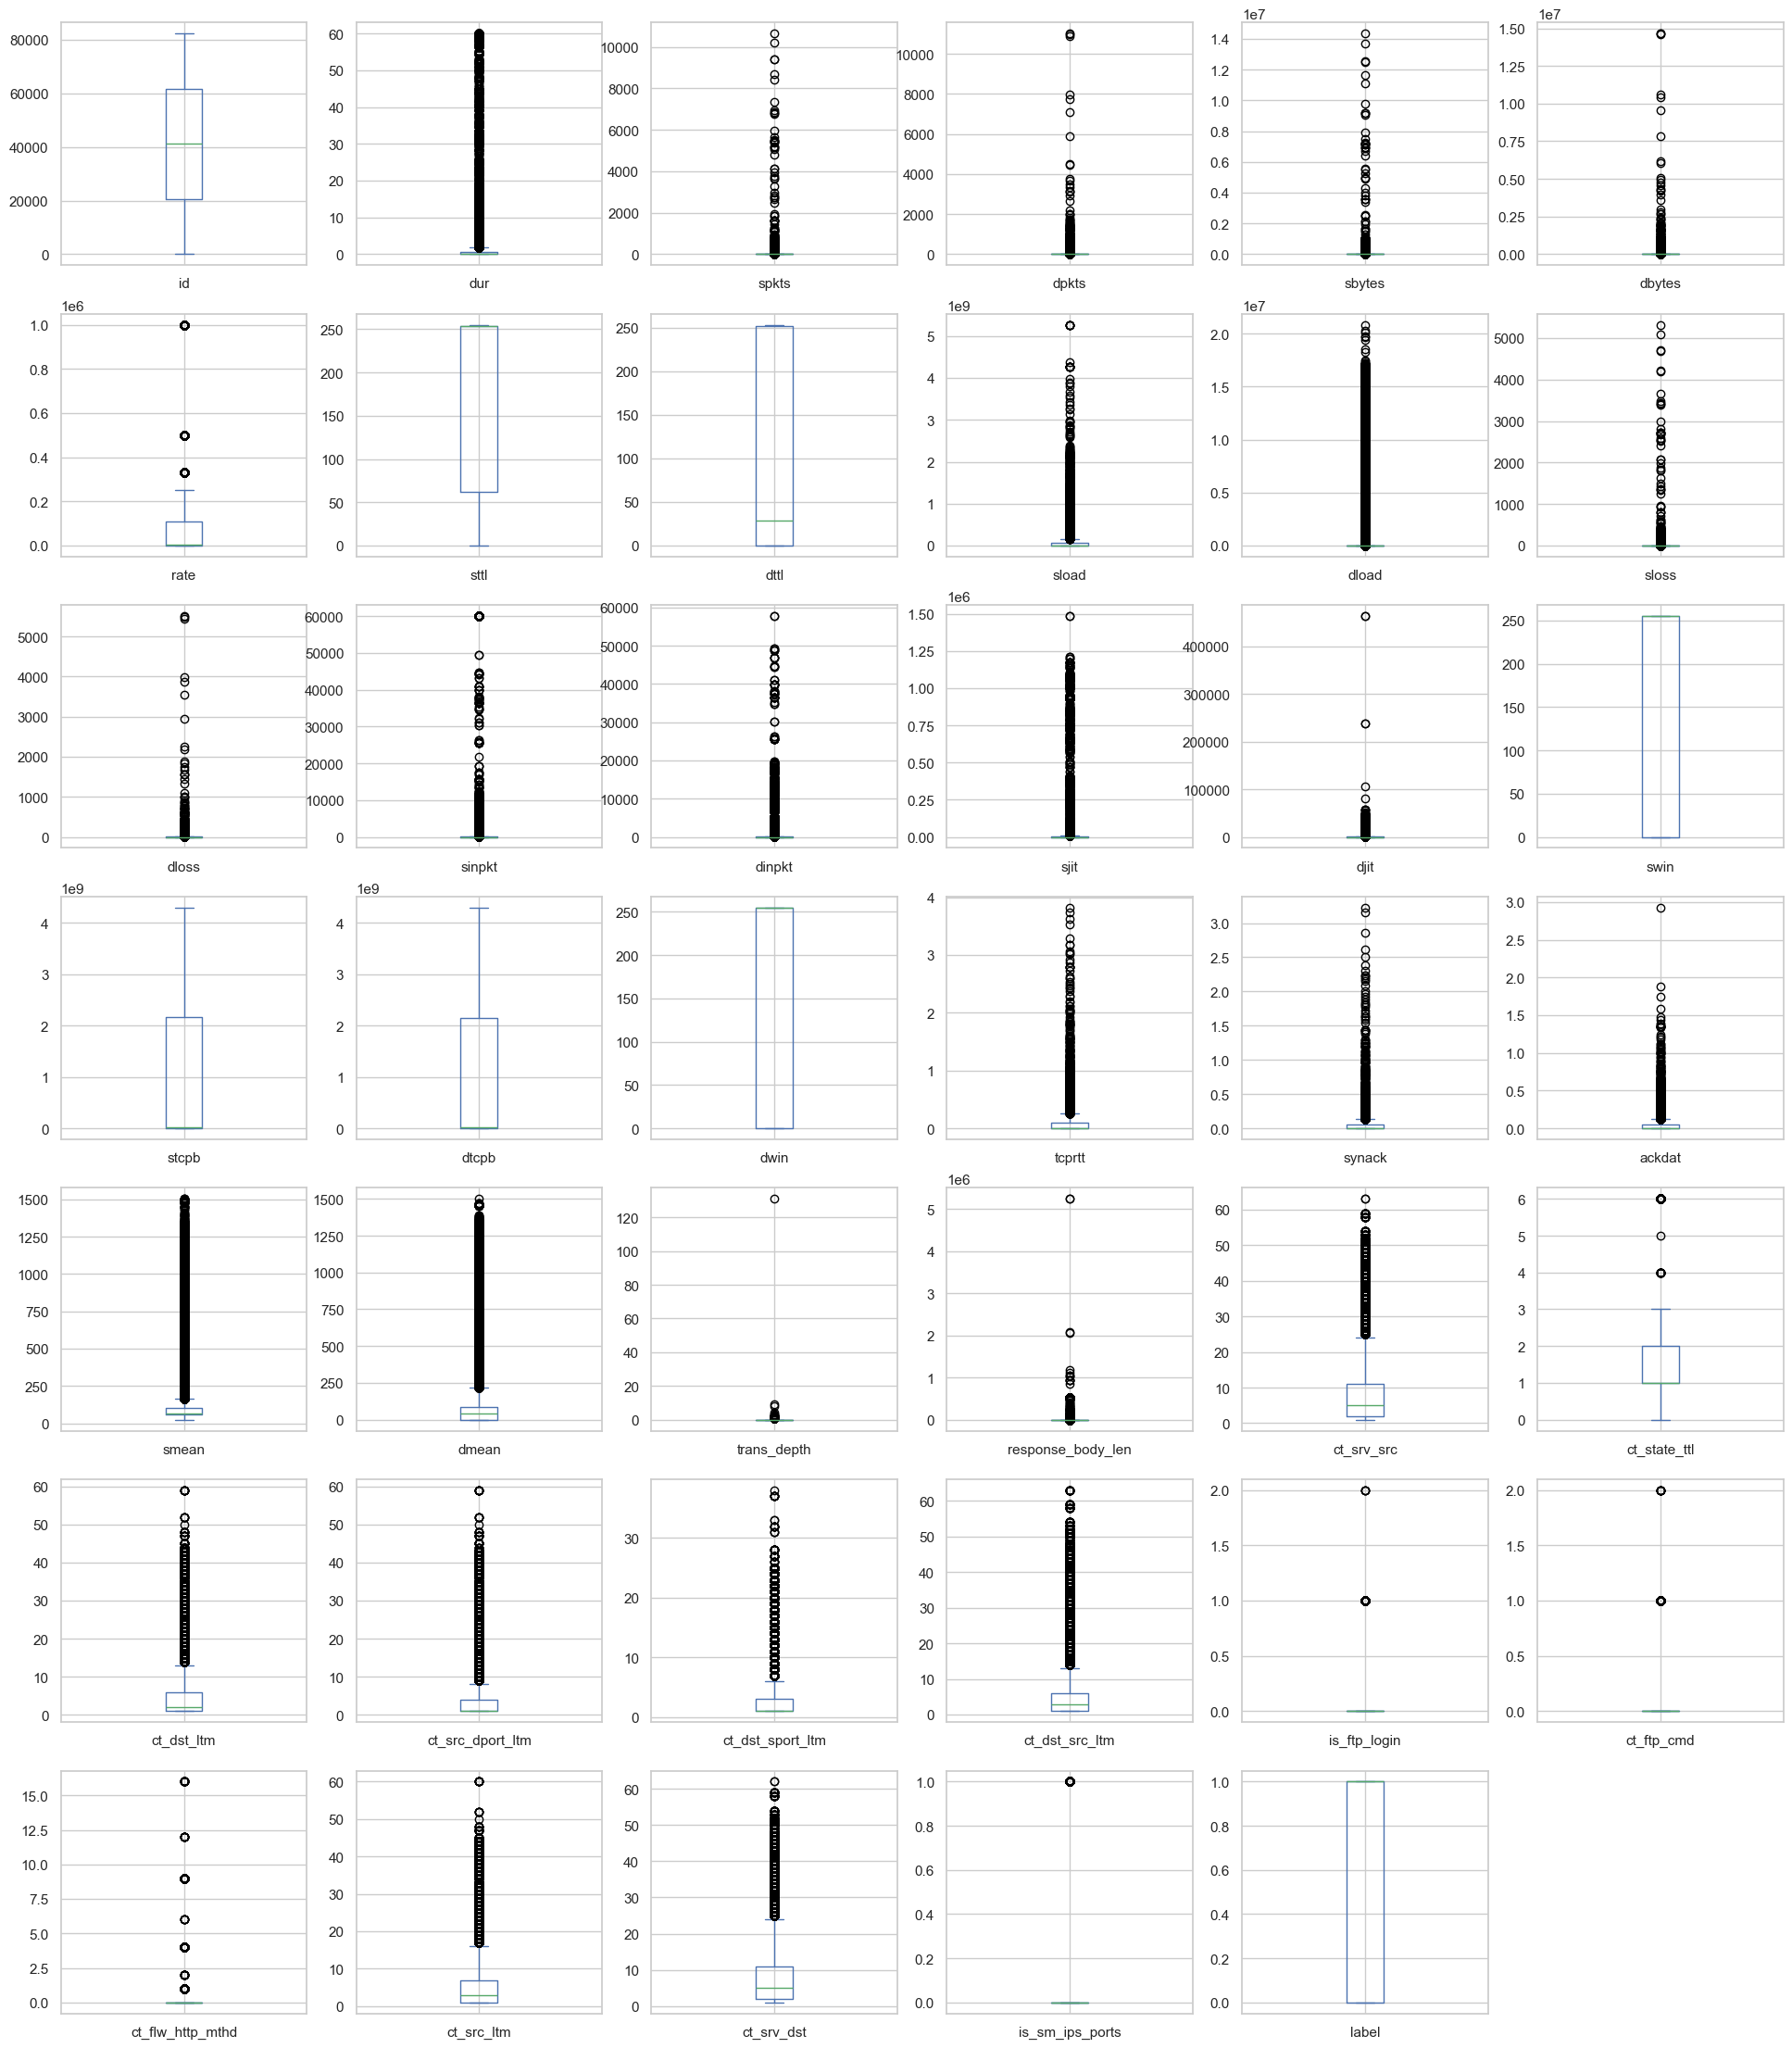

In [12]:
plt.figure(figsize=(24, 32))
df.plot(kind='box', subplots=True, layout=(8, 6), figsize=(24, 32))
plt.show()

There is no too much outlier to misslead the model so i will not drop the outliers

# 3.4 CLASSIFY ATTACK OR NOT

In [13]:
attack_n = []
for i in df['attack_cat']:
    if i == 'normal':
        attack_n.append("normal")
    else:
        attack_n.append("attack")

df['attack'] = attack_n


In [14]:
df['attack'].unique()

array(['attack'], dtype=object)

# 4. EDA - VISUALIZATIONS

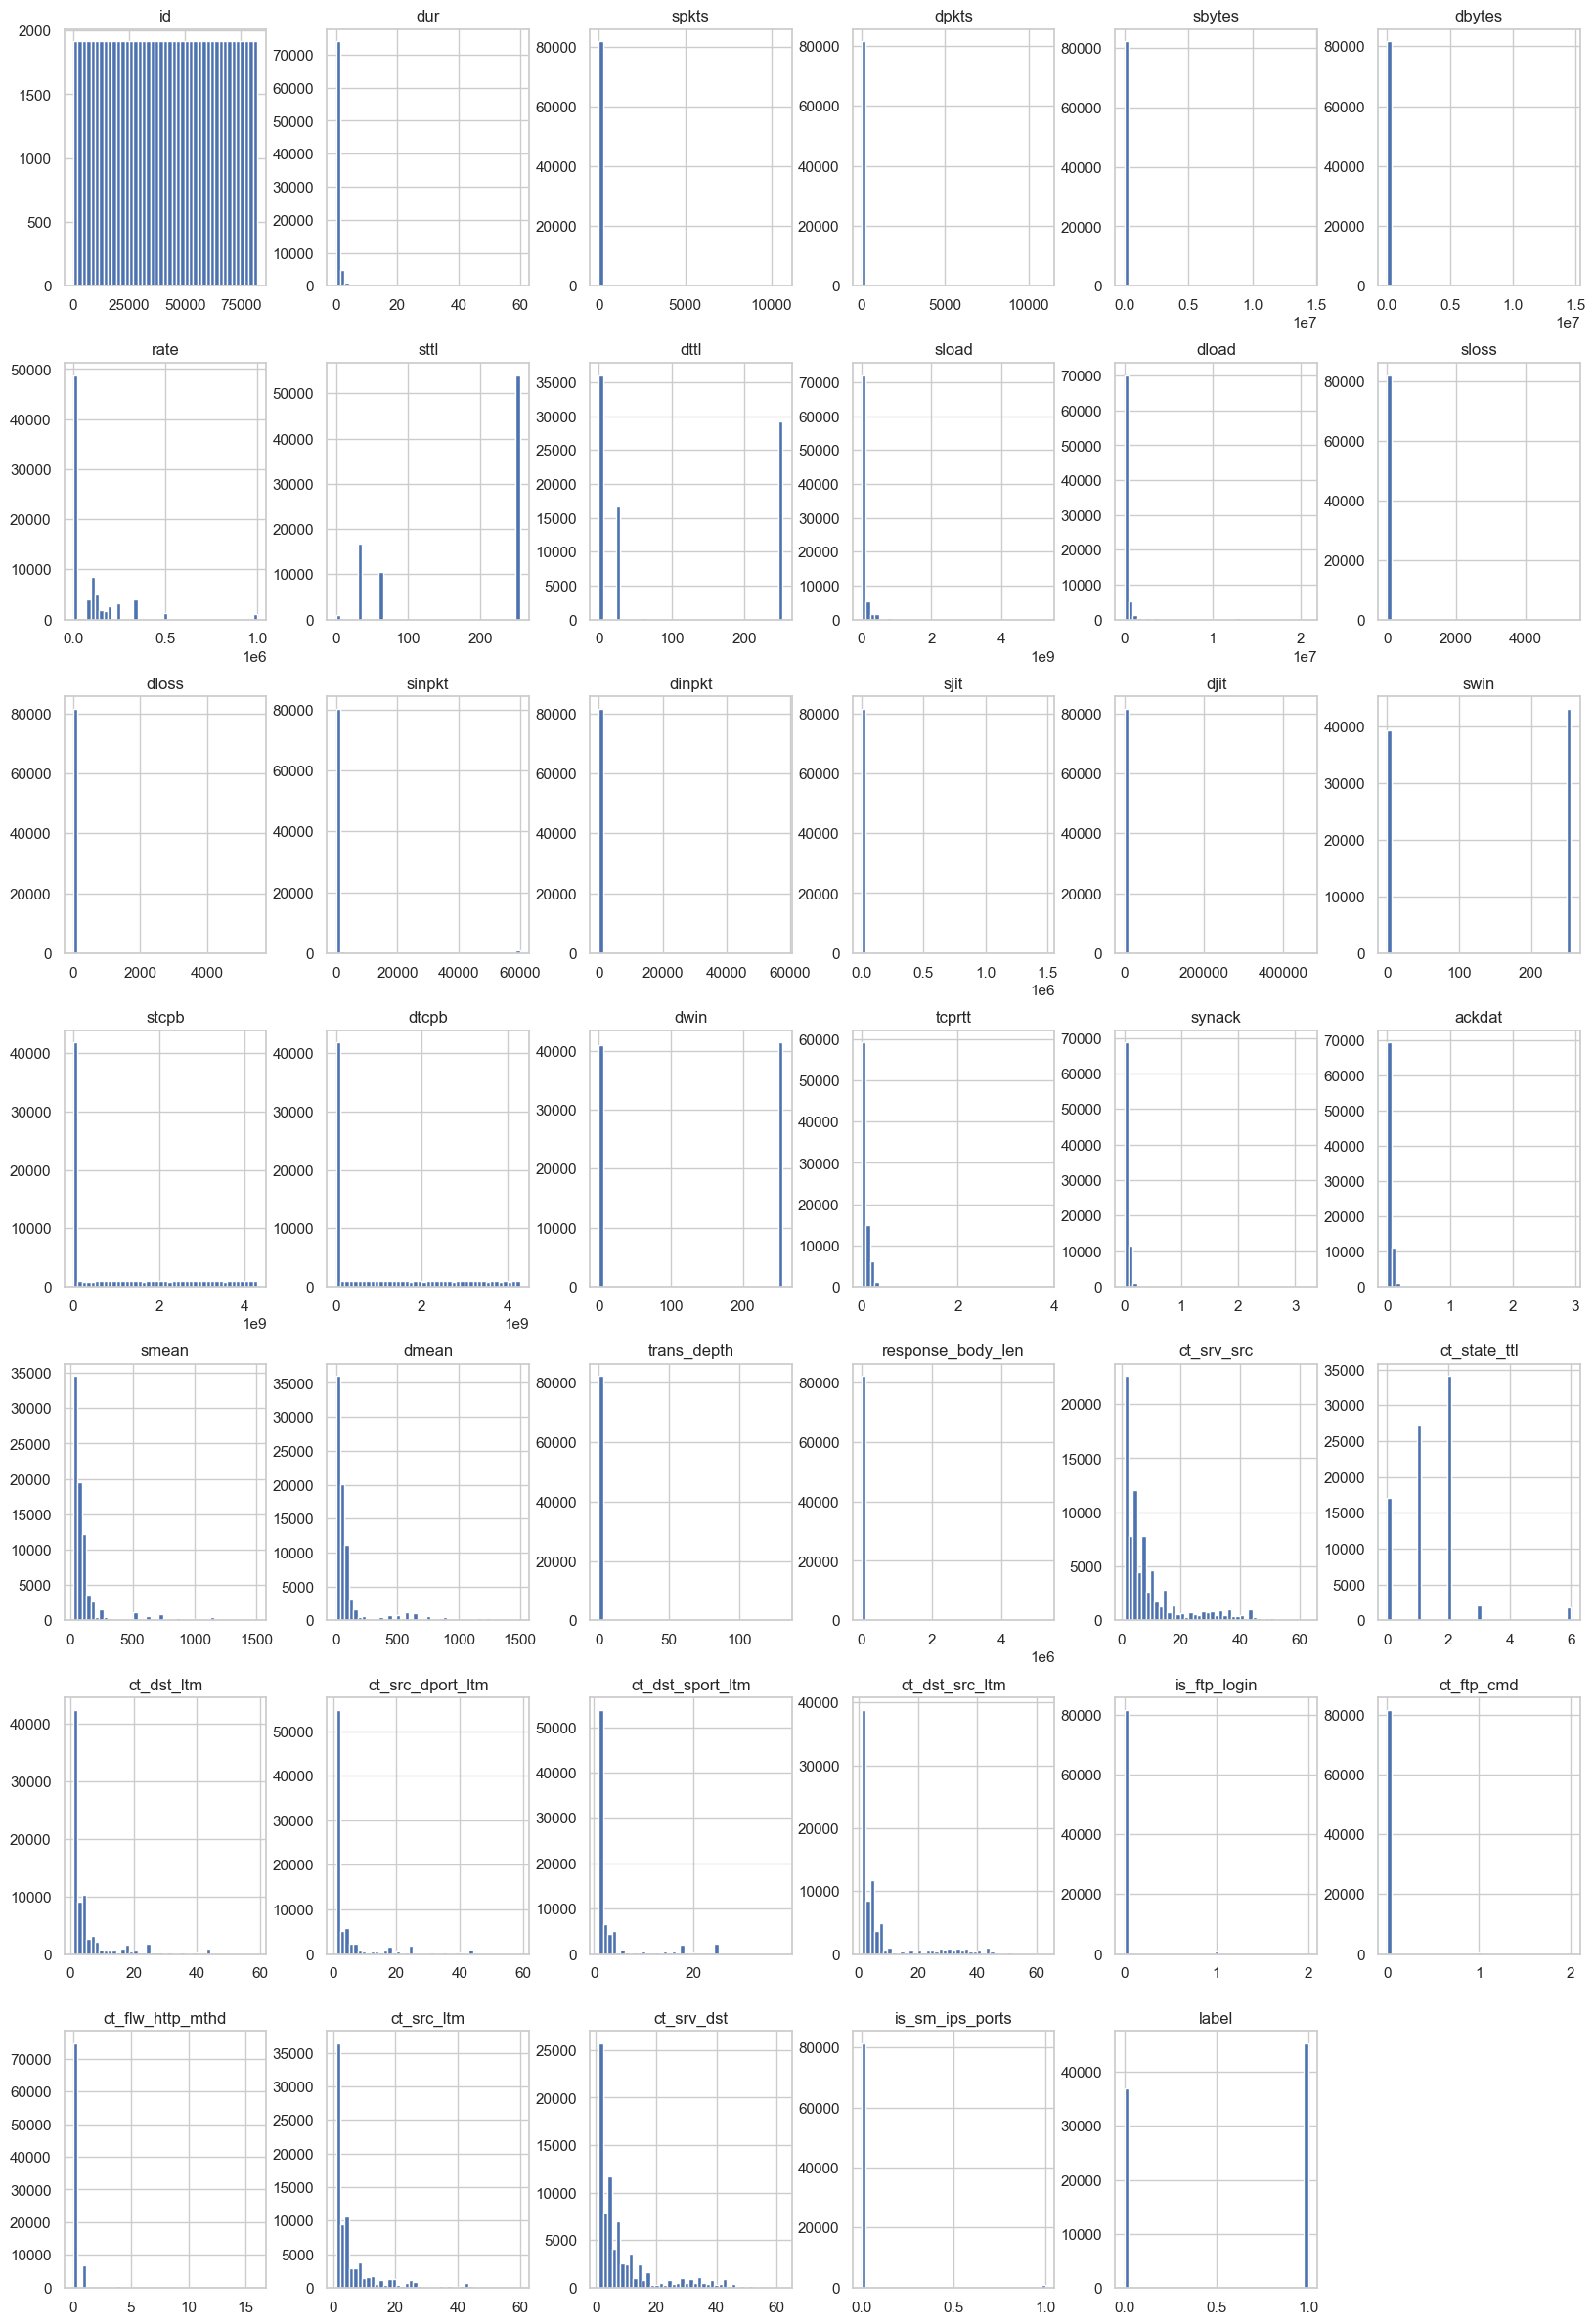

In [15]:
df.hist(bins=43,figsize=(20,30));

General visualization in order to get insights

# 4.1 Protocol Type

In [16]:
import pandas as pd

# Load dataset
df_train = pd.read_csv('UNSW_NB15_training-set.csv')
#df_train = pd.read_csv("/Users/premkumaraskani/Downloads/Kadhar_Final_code/UNSW_NB15_training-set.csv")

# View columns
print(df_train.columns)



Index(['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label'],
      dtype='object')


In [17]:
# Unique values in the 'proto' column
unique_protocols = df_train['proto'].unique()
print("Unique protocol types:", unique_protocols)


Unique protocol types: ['udp' 'arp' 'tcp' 'igmp' 'ospf' 'sctp' 'gre' 'ggp' 'ip' 'ipnip' 'st2'
 'argus' 'chaos' 'egp' 'emcon' 'nvp' 'pup' 'xnet' 'mux' 'dcn' 'hmp' 'prm'
 'trunk-1' 'trunk-2' 'xns-idp' 'leaf-1' 'leaf-2' 'irtp' 'rdp' 'netblt'
 'mfe-nsp' 'merit-inp' '3pc' 'idpr' 'ddp' 'idpr-cmtp' 'tp++' 'ipv6' 'sdrp'
 'ipv6-frag' 'ipv6-route' 'idrp' 'mhrp' 'i-nlsp' 'rvd' 'mobile' 'narp'
 'skip' 'tlsp' 'ipv6-no' 'any' 'ipv6-opts' 'cftp' 'sat-expak' 'ippc'
 'kryptolan' 'sat-mon' 'cpnx' 'wsn' 'pvp' 'br-sat-mon' 'sun-nd' 'wb-mon'
 'vmtp' 'ttp' 'vines' 'nsfnet-igp' 'dgp' 'eigrp' 'tcf' 'sprite-rpc' 'larp'
 'mtp' 'ax.25' 'ipip' 'aes-sp3-d' 'micp' 'encap' 'pri-enc' 'gmtp' 'ifmp'
 'pnni' 'qnx' 'scps' 'cbt' 'bbn-rcc' 'igp' 'bna' 'swipe' 'visa' 'ipcv'
 'cphb' 'iso-tp4' 'wb-expak' 'sep' 'secure-vmtp' 'xtp' 'il' 'rsvp' 'unas'
 'fc' 'iso-ip' 'etherip' 'pim' 'aris' 'a/n' 'ipcomp' 'snp' 'compaq-peer'
 'ipx-n-ip' 'pgm' 'vrrp' 'l2tp' 'zero' 'ddx' 'iatp' 'stp' 'srp' 'uti' 'sm'
 'smp' 'isis' 'ptp' 'fire' 'crtp

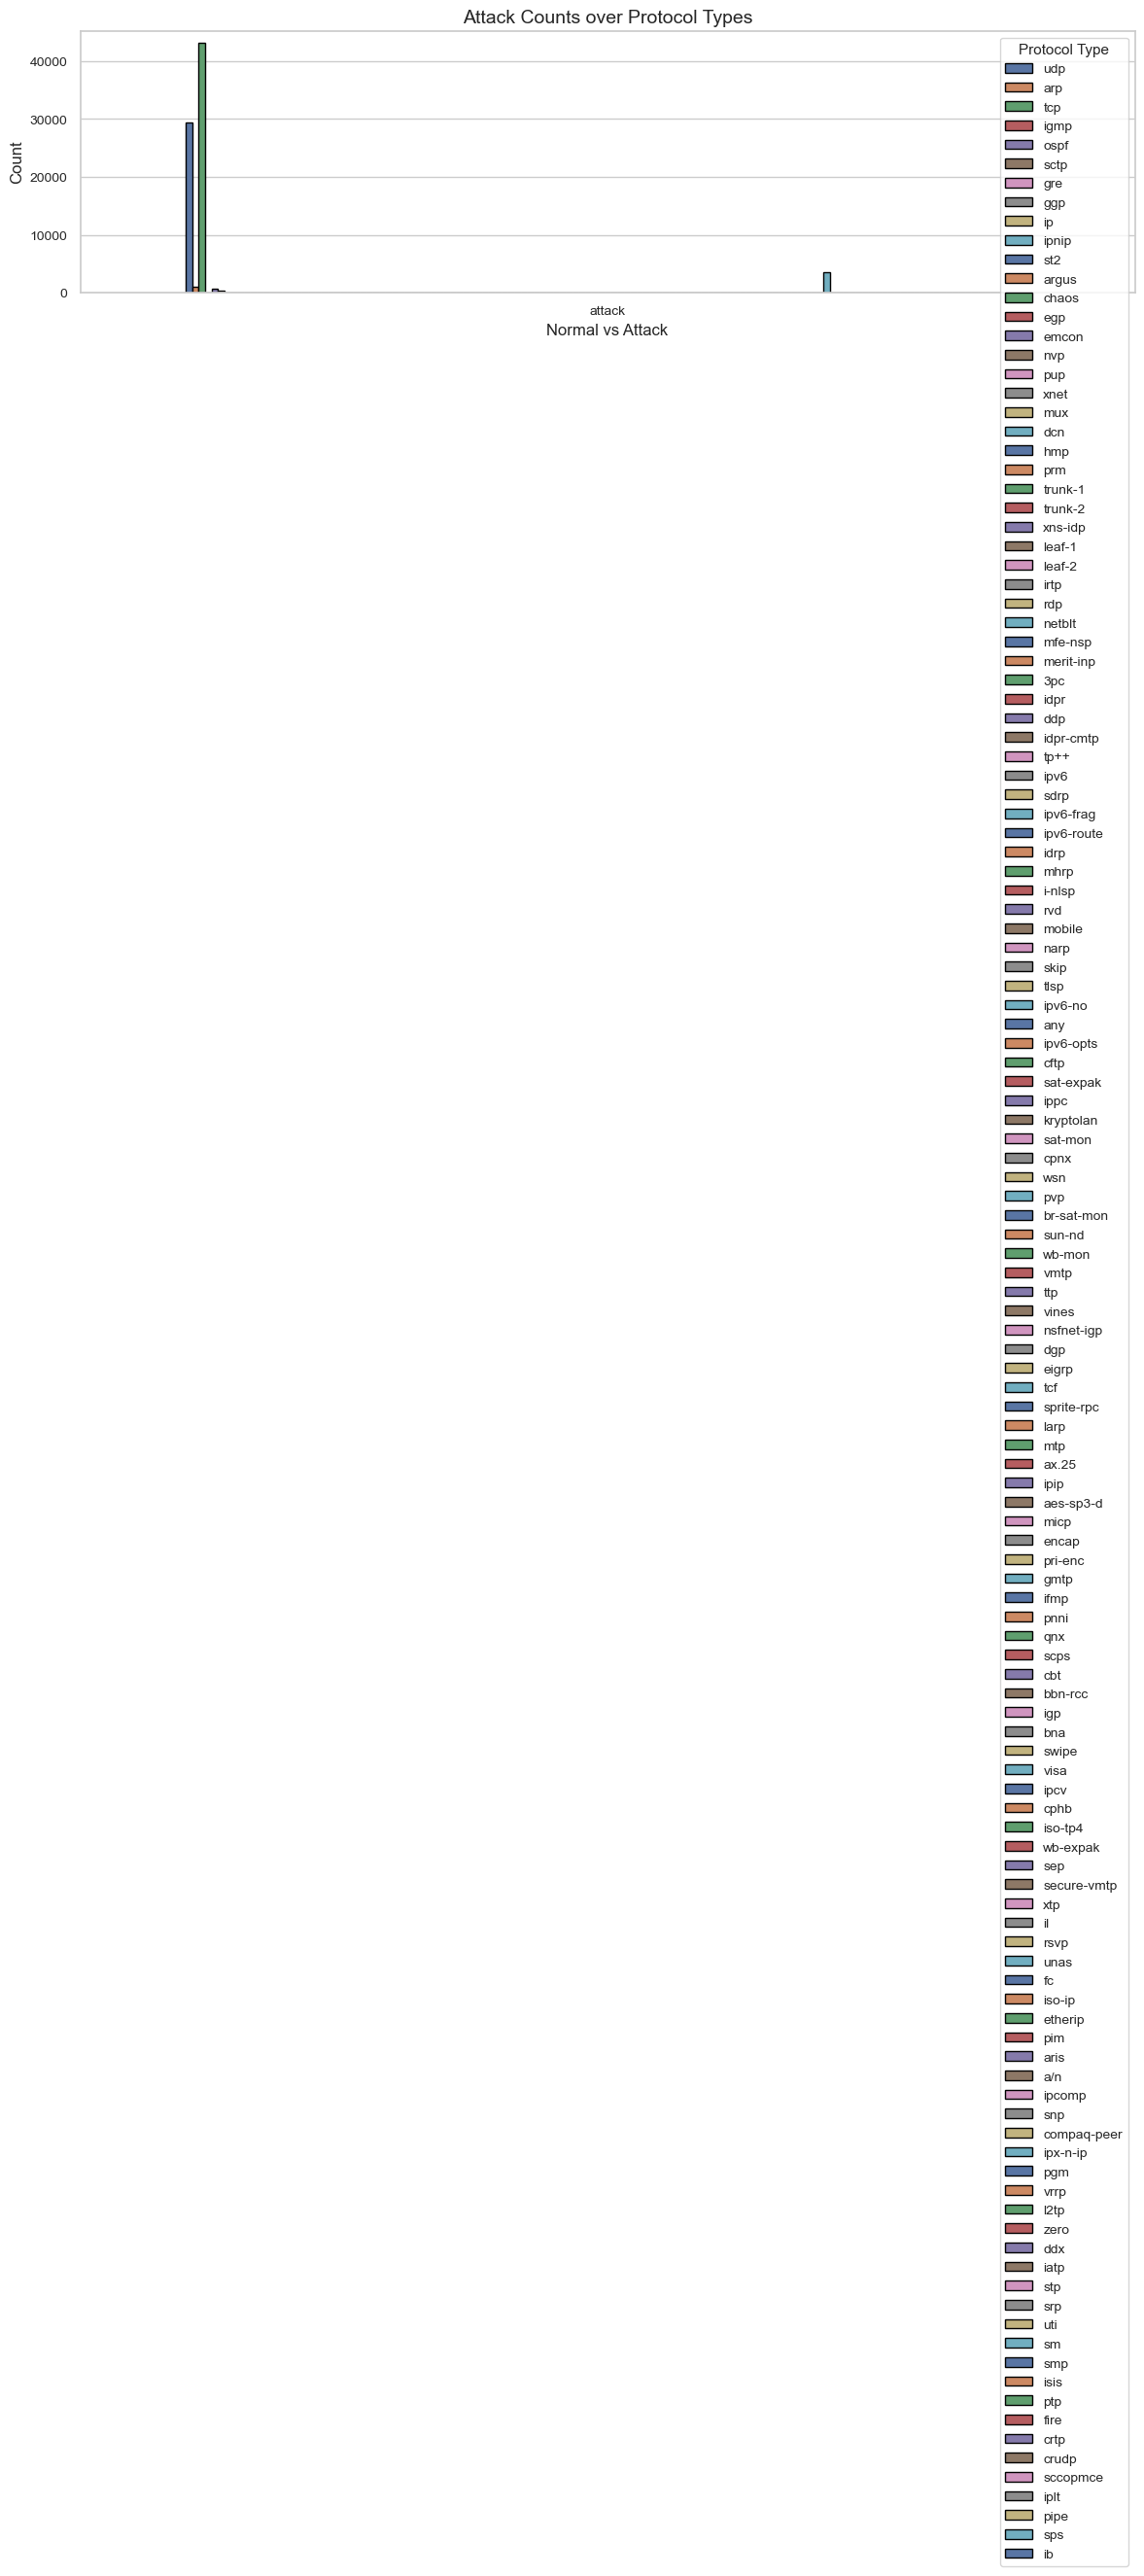

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set whitegrid style for clean visuals
sns.set(style="whitegrid")

# Create the figure
plt.figure(figsize=(14, 3.5))  # smaller height for better compactness

# Bar plot: 'attack' on x-axis, grouped by 'proto'
sns.countplot(
    x='attack',
    data=df,
    hue='proto',
    palette='deep',
    edgecolor='black'
)

# Smaller tick font size for better readability
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Label axes clearly
plt.xlabel('Normal vs Attack', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Title
plt.title('Attack Counts over Protocol Types', fontsize=14)

# Legend styling
plt.legend(title='Protocol Type', fontsize=10, title_fontsize=11, loc='upper right')

# Tight layout for cleaner spacing
plt.tight_layout()

# Show the plot
plt.show()


In [19]:
# So we can see that most of the attacks are from tcp, then udp, and least attack comes from icmp

In [20]:
print(df.columns)


Index(['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label', 'attack'],
      dtype='object')


In [21]:
df["proto"].value_counts(normalize=True)

proto
tcp          0.523
udp          0.357
unas         0.043
arp          0.012
ospf         0.008
              ... 
br-sat-mon   0.000
pvp          0.000
wsn          0.000
ib           0.000
igmp         0.000
Name: proportion, Length: 131, dtype: float64

# 4.2 Service used general

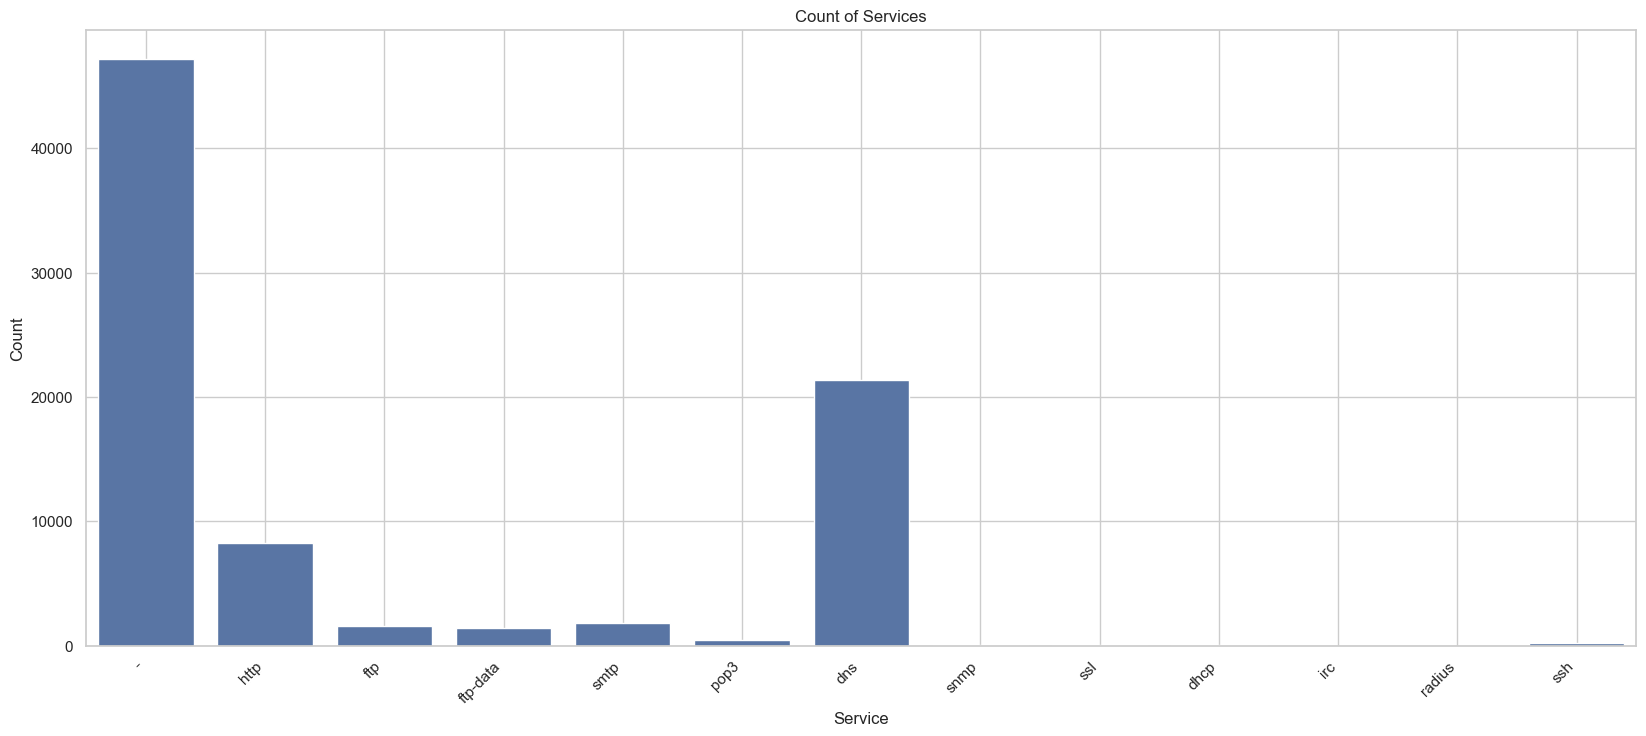

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))  # Adjusted figure size
ax = sns.countplot(x='service', data=df)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")  # Rotated labels
plt.xlabel('Service')
plt.ylabel('Count')
plt.title('Count of Services')
plt.grid(True)
plt.show()


In [23]:
# Services most used in general follows as, http,private,domain_u,smtp, ftp,other..

# 4.3 Service used effect on attacks

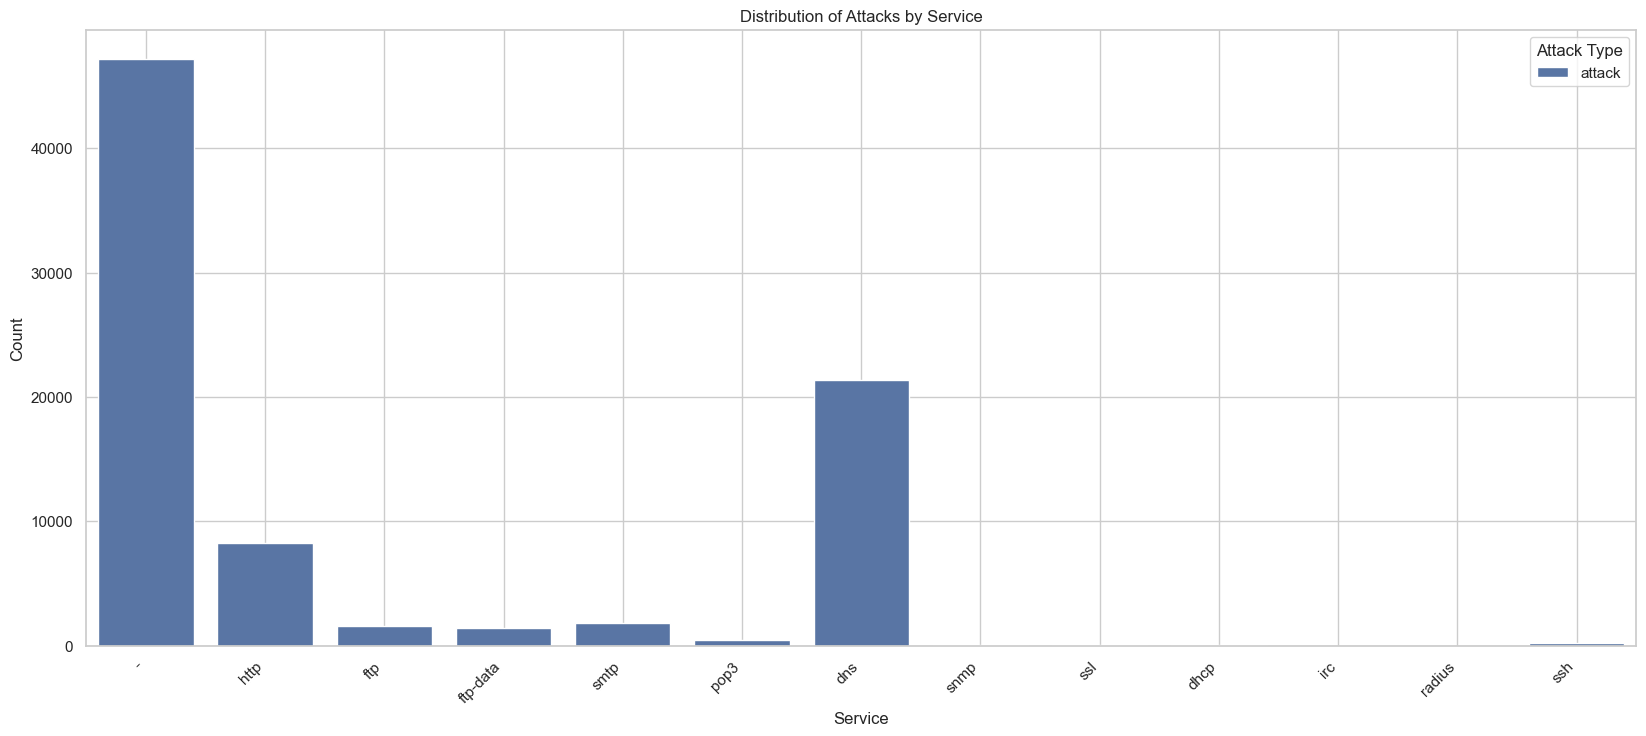

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))  # Adjusted figure size
ax = sns.countplot(x='service', hue='attack', data=df)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")  # Rotated labels
plt.xlabel('Service')
plt.ylabel('Count')
plt.title('Distribution of Attacks by Service')
plt.legend(title='Attack Type')
plt.grid(True)
plt.show()


In [25]:
#we can see that private attacks is most common service 

# 4.4 Kernel Density Estimate (KDE) Plot of Duration by Flag

In [26]:
print(df.columns)


Index(['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label', 'attack'],
      dtype='object')


<Figure size 1200x800 with 0 Axes>

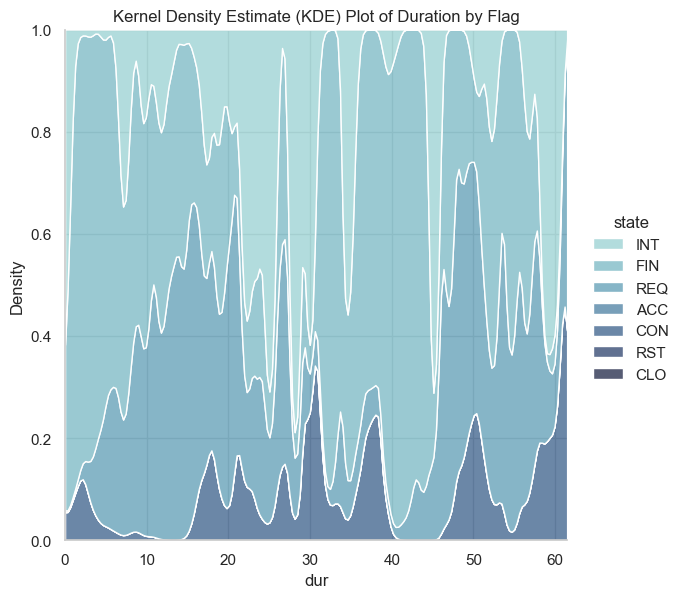

In [27]:

plt.figure(figsize=(12, 8))
sns.displot(
    data=df,
    x="dur",
    hue="state",
    kind="kde",
    height=6,
    multiple="fill",
    clip=(0, None),
    palette="ch:rot=-.25,hue=1,light=.75",
)
plt.title('Kernel Density Estimate (KDE) Plot of Duration by Flag')
plt.grid(True)
plt.show()


# 4.5 Distribution of Attack Types by Guest Login

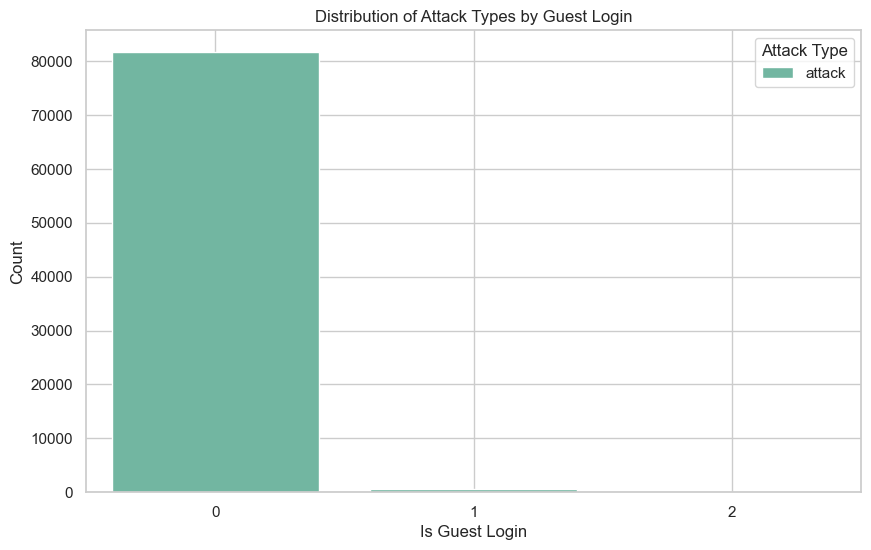

In [28]:
plt.figure(figsize=(10, 6))
# sns.countplot(x='is_guest_login', hue='attack', data=df, palette='Set2')
sns.countplot(x='is_ftp_login', hue='attack', data=df, palette='Set2')
plt.xlabel('Is Guest Login')
plt.ylabel('Count')
plt.title('Distribution of Attack Types by Guest Login')
plt.legend(title='Attack Type')
plt.grid(True)
plt.show()


we can clearly say that attacks are comes when guest is not login

# 5. PREPROCESSING

# 5.1 ENCODING

In [29]:
cat_features = df.select_dtypes(include='object').columns
cat_features

Index(['proto', 'service', 'state', 'attack_cat', 'attack'], dtype='object')

In [30]:
# from sklearn import preprocessing
# le=preprocessing.LabelEncoder()
# clm=['proto', 'service', 'state', 'attack']
# for x in clm:
#     df[x]=le.fit_transform(df[x])

from sklearn import preprocessing
le = preprocessing.LabelEncoder()
clm = ['proto', 'service', 'state', 'attack_cat']
for x in clm:
    df[x] = le.fit_transform(df[x])


In [31]:
df['attack'] = df['attack_cat'].apply(lambda x: 'normal' if x == le.transform(['Normal'])[0] else 'attack')
df['attack'] = preprocessing.LabelEncoder().fit_transform(df['attack'])



In [32]:
X = df.drop(['attack'], axis=1)
y = df['attack']
feature_names = X.columns.tolist()

# 5.2 TRAIN-TEST-SPLIT

In [33]:
from sklearn.model_selection import train_test_split

X = df.drop(["attack"], axis=1)
y = df["attack"]

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.1,random_state=43) 




#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=43, stratify=y)

In [34]:
train_index = X_train.columns
train_index

Index(['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label'],
      dtype='object')

# 5.3 Feature Engineering

In [35]:
from sklearn.feature_selection import mutual_info_classif
mutual_info = mutual_info_classif(X_train, y_train)
mutual_info = pd.Series(mutual_info)
mutual_info.index = train_index
mutual_info.sort_values(ascending=False)



label               0.701
attack_cat          0.695
id                  0.688
sbytes              0.457
smean               0.357
sload               0.344
dbytes              0.294
ct_state_ttl        0.277
rate                0.263
dur                 0.254
dmean               0.253
dttl                0.243
dinpkt              0.236
sttl                0.220
dload               0.212
dpkts               0.206
synack              0.205
tcprtt              0.203
sinpkt              0.198
ct_dst_sport_ltm    0.191
state               0.190
ackdat              0.185
sjit                0.161
spkts               0.155
djit                0.148
proto               0.140
dloss               0.118
ct_src_dport_ltm    0.117
ct_srv_dst          0.114
sloss               0.110
swin                0.098
ct_srv_src          0.093
stcpb               0.088
service             0.086
dtcpb               0.083
dwin                0.079
ct_dst_src_ltm      0.068
ct_dst_ltm          0.061
ct_src_ltm  

In [36]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif

# Assume df is your DataFrame

# Identify categorical columns (example based on your data)
categorical_cols = ['proto', 'service', 'state', 'attack_cat']

# One-hot encode categorical features
X = df.drop(columns=['label'])  # features
X_encoded = pd.get_dummies(X, columns=categorical_cols)

# Target
y = df['label']

# If y is not numeric (it looks numeric here, so this might not be needed)
# le = LabelEncoder()
# y_encoded = le.fit_transform(y)
y_encoded = y

# Now calculate mutual info
mutual_info = mutual_info_classif(X_encoded, y_encoded, discrete_features='auto')

# Create a pandas Series for easier inspection
mutual_info_series = pd.Series(mutual_info, index=X_encoded.columns).sort_values(ascending=False)

print(mutual_info_series)


attack         0.699
attack_cat_6   0.699
id             0.688
sbytes         0.460
smean          0.358
                ... 
proto_104      0.000
proto_103      0.000
proto_102      0.000
proto_33       0.000
proto_55       0.000
Length: 202, dtype: float64


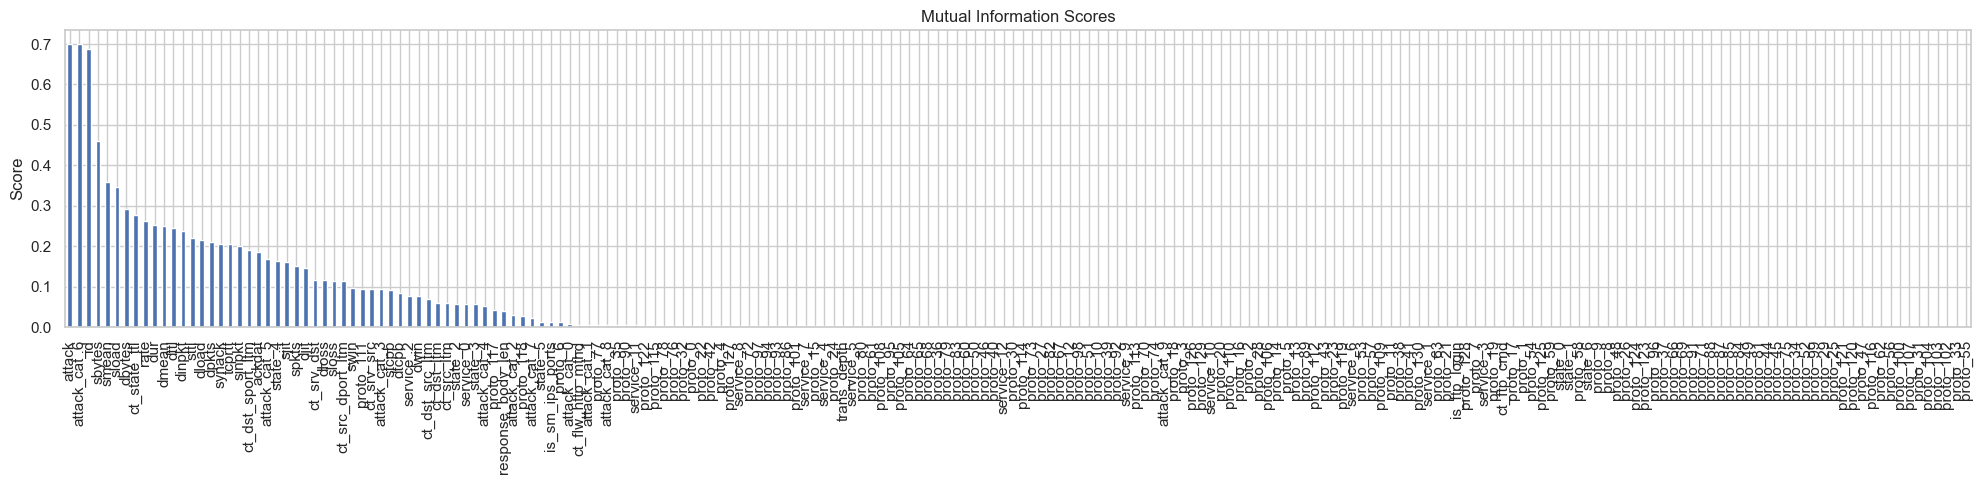

In [37]:
# mutual_info.sort_values(ascending=False).plot.bar(figsize=(20, 5));

mutual_info_series.plot.bar(figsize=(20, 5))
plt.title('Mutual Information Scores')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

# 5.4 Feature Selection

In [38]:
from sklearn.feature_selection import SelectKBest
Select_features = SelectKBest(mutual_info_classif, k=30)
Select_features.fit(X_train, y_train)
train_index[Select_features.get_support()]

Index(['id', 'dur', 'proto', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes',
       'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt',
       'dinpkt', 'sjit', 'djit', 'tcprtt', 'synack', 'ackdat', 'smean',
       'dmean', 'ct_state_ttl', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
       'ct_srv_dst', 'attack_cat', 'label'],
      dtype='object')

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif, SelectKBest

# Step A: Drop target
X = df.drop(columns=['label'])

# Step B: One-hot encode categorical columns
categorical_cols = ['proto', 'service', 'state', 'attack_cat']
X_encoded = pd.get_dummies(X, columns=categorical_cols)

# Step C: Encode y (label) to numeric if not already
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(df['label']) 

# Step D: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.3, random_state=42)


In [40]:
selector = SelectKBest(mutual_info_classif, k=30)
selector.fit(X_train, y_train)

# Get selected feature names
selected_feature_names = X_train.columns[selector.get_support()]
print("Selected top 30 features:\n", selected_feature_names)


Selected top 30 features:
 Index(['id', 'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl',
       'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit',
       'djit', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'ct_state_ttl',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_srv_dst', 'attack',
       'state_4', 'attack_cat_5', 'attack_cat_6'],
      dtype='object')


In [41]:
print(df.head())  
# or simply
df.head()


   id   dur  proto  service  state  spkts  dpkts  sbytes  dbytes       rate  \
0   1 0.000    117        0      4      2      0     496       0  90909.090   
1   2 0.000    117        0      4      2      0    1762       0 125000.000   
2   3 0.000    117        0      4      2      0    1068       0 200000.005   
3   4 0.000    117        0      4      2      0     900       0 166666.661   
4   5 0.000    117        0      4      2      0    2126       0 100000.003   

   ...  ct_dst_src_ltm  is_ftp_login  ct_ftp_cmd  ct_flw_http_mthd  \
0  ...               2             0           0                 0   
1  ...               2             0           0                 0   
2  ...               3             0           0                 0   
3  ...               3             0           0                 0   
4  ...               3             0           0                 0   

   ct_src_ltm  ct_srv_dst  is_sm_ips_ports  attack_cat  label  attack  
0           1           2       

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label,attack
0,1,0.000,117,0,4,2,0,496,0,90909.090,...,2,0,0,0,1,2,0,6,0,1
1,2,0.000,117,0,4,2,0,1762,0,125000.000,...,2,0,0,0,1,2,0,6,0,1
2,3,0.000,117,0,4,2,0,1068,0,200000.005,...,3,0,0,0,1,3,0,6,0,1
3,4,0.000,117,0,4,2,0,900,0,166666.661,...,3,0,0,0,2,3,0,6,0,1
4,5,0.000,117,0,4,2,0,2126,0,100000.003,...,3,0,0,0,2,3,0,6,0,1


In [42]:
columns = ['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes','dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss']

print(df.columns)
X = df[columns]
y = df['label']

# One-hot encode categorical columns only (no scaling)
X_encoded = pd.get_dummies(X, columns=['proto', 'service', 'state'])

# Encode target if not numeric
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42)

# Select top 15 features with mutual info (no scaling done here)
selector = SelectKBest(mutual_info_classif, k=15)
selector.fit(X_train, y_train)

top_features = X_train.columns[selector.get_support()]
print("Top 15 selected features:")
print(top_features)

Index(['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label', 'attack'],
      dtype='object')
Top 15 selected features:
Index(['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl',
       'sload', 'dload', 'sloss', 'dloss', 'proto_111', 'service_2',
       'state_4'],
      dtype='object')


# 5.5 Scaling

In [43]:
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()

# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test) # we use only transform in order to prevent data leakage

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




# 6. MODEL BUILD

In [44]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

In [45]:

# XGBoost_model = XGBClassifier(random_state=42)
# Logistic_model = LogisticRegression(random_state=42)


XGBoost_model = XGBClassifier(random_state=42)
Logistic_model = LogisticRegression(random_state=42)

In [47]:
# XGBoost = XGBoost_model.fit(X_train,y_train)
# Logistic = Logistic_model.fit(X_train,y_train)

XGBoost_model.fit(X_train_scaled, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [48]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

In [49]:
# Revised evaluation function for test set only
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    print('Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    if y_score is not None:
        print(f"ROC-AUC: {roc_auc_score(y_test, y_score):.4f}")

In [49]:
# eval_metric(Logistic_model, X_train, y_train, X_test, y_test)
#evaluate_model(Logistic_model, X_test_scaled, y_test)


Confusion Matrix:
[[ 9623  1524]
 [ 2469 11084]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.86      0.83     11147
           1       0.88      0.82      0.85     13553

    accuracy                           0.84     24700
   macro avg       0.84      0.84      0.84     24700
weighted avg       0.84      0.84      0.84     24700

Accuracy: 0.8383
Precision: 0.8791
Recall: 0.8178
F1 Score: 0.8474
ROC-AUC: 0.9451


# 6.1 HYPERPARAMETER TUNING

In [51]:
from sklearn.model_selection import GridSearchCV

# param_grid = {
#     "n_estimators": [50, 64, 100, 128],
#     "max_depth": [2, 3, 4, 5, 6],
#     "learning_rate": [0.01, 0.03, 0.05, 0.1],
#     "subsample": [0.5, 0.8],
#     "colsample_bytree": [0.5, 0.8]
# }

param_grid = {
    "n_estimators": [50, 64, 100, 128],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.5, 0.8],
    "colsample_bytree": [0.5, 0.8]
}

XGB_grid_model = GridSearchCV(XGBoost_model, param_grid, scoring='f1', n_jobs=-1, return_train_score=True)
XGB_grid_model.fit(X_train_scaled, y_train)
# grid_model = GridSearchCV(XGBClassifier(random_state=42), param_grid, scoring='f1', n_jobs=-1, return_train_score=True)
# grid_model.fit(X_train_scaled, y_train)

print("Best Parameters:", XGB_grid_model.best_params_)
print("Best F1 Score:", XGB_grid_model.best_score_)

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 128, 'subsample': 0.5}
Best F1 Score: 0.9426765876910945


In [51]:
# param_grid = {
#     "n_estimators": [50,64,100,128],
#     "max_depth": [2, 3, 4,5,6],
#     "learning_rate": [0.01,0,0.03, 0.05, 0.1],
#     "subsample": [0.5, 0.8],
#     "colsample_bytree": [0.5, 0.8]
# }

In [52]:
# from sklearn.model_selection import GridSearchCV

# XGB_model = XGBClassifier(random_state=42) #initialize the model

# XGB_grid_model = GridSearchCV(XGB_model,
#                         param_grid,
#                         scoring="f1",
#                         n_jobs=-1,
#                         return_train_score=True).fit(X_train, y_train)

In [52]:
XGB_grid_model.best_score_

0.9426765876910945

In [53]:
XGB_grid_model.best_params_

{'colsample_bytree': 0.8,
 'learning_rate': 0.1,
 'max_depth': 6,
 'n_estimators': 128,
 'subsample': 0.5}

# 6.2 FINAL MODEL

In [54]:
XGB_model = XGBClassifier(
    colsample_bytree=0.5,
    learning_rate=0.1,
    max_depth=6,
    n_estimators=128,
    subsample=0.8
)

# Fit the classifier to your data
XGB_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=128,
              n_jobs=None, num_parallel_tree=None, ...)

# 6.3 EVALUATION

In [55]:
y_pred = XGB_model.predict(X_test)
y_pred_proba = XGB_model.predict_proba(X_test)

xgb_f1 = f1_score(y_test, y_pred)
xgb_recall = recall_score(y_test, y_pred)
xgb_auc = roc_auc_score(y_test, y_pred_proba[:,1])


In [56]:
xgb_auc

0.9869670315577945

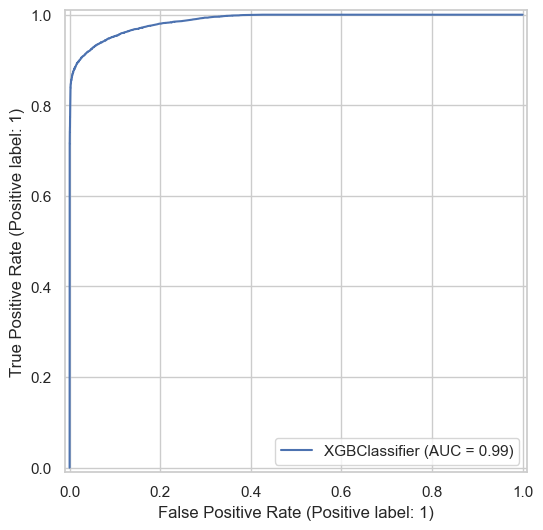

In [57]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(XGB_model, X_test, y_test);

In [58]:
evaluate_model(XGB_model, X_test, y_test)


Confusion Matrix:
[[10733   414]
 [ 1146 12407]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93     11147
           1       0.97      0.92      0.94     13553

    accuracy                           0.94     24700
   macro avg       0.94      0.94      0.94     24700
weighted avg       0.94      0.94      0.94     24700

Accuracy: 0.9368
Precision: 0.9677
Recall: 0.9154
F1 Score: 0.9409
ROC-AUC: 0.9870


# 7. FEATURE IMPORTANCE

In [59]:
print(X_train.shape)         # Shape before scaling
print(X_train_scaled.shape)  # Shape after scaling
print(len(feature_names))    # Length of feature names
print(len(XGBoost_model.feature_importances_))  # Length of feature importance


(57632, 163)
(57632, 163)
45
163


In [60]:
model = XGB_model
model.feature_importances_

# feats = pd.DataFrame(index=X[columns].columns, data= model.feature_importances_, columns=['XGB_importance'])

# ada_imp_feats = feats.sort_values("XGB_importance", ascending = False)
# ada_imp_feats


# Restore the full feature set
# X = df.drop(['attack'], axis=1)

# Now use this for feature importance
# feats = pd.DataFrame(
#     index=X.columns,
#     data=model.feature_importances_,
#     columns=['XGB_importance']
# )

# ada_imp_feats = feats.sort_values("XGB_importance", ascending=False)
# ada_imp_feats


# feats = pd.DataFrame(index=feature_names, data=XGB_model.feature_importances_, columns=['XGB_importance'])
# ada_imp_feats = feats.sort_values("XGB_importance", ascending=False)
# ada_imp_feats

# plt.figure(figsize=(10, 6))
# sns.barplot(x=ada_imp_feats['XGB_importance'], y=ada_imp_feats.index)
# plt.title('XGBoost Feature Importances')
# plt.tight_layout()
# plt.show()

# Step 1: Define full features
X = df.drop(['attack'], axis=1)
y = df['attack']

# Step 2: Save correct feature names (MUST be done here!)
feature_names = X.columns.tolist()

# Step 3: Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=43, stratify=y)

# Step 4: Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 5: Train
XGBoost_model = XGBClassifier(random_state=42)
XGBoost_model.fit(X_train_scaled, y_train)

# Step 6: Feature Importance
feats = pd.DataFrame(index=feature_names, data=XGBoost_model.feature_importances_, columns=['XGB_importance'])
ada_imp_feats = feats.sort_values("XGB_importance", ascending=False)
print(ada_imp_feats)


                   XGB_importance
label                       1.000
dwin                        0.000
synack                      0.000
ackdat                      0.000
smean                       0.000
dmean                       0.000
trans_depth                 0.000
response_body_len           0.000
ct_srv_src                  0.000
ct_state_ttl                0.000
ct_dst_ltm                  0.000
ct_src_dport_ltm            0.000
ct_dst_sport_ltm            0.000
ct_dst_src_ltm              0.000
is_ftp_login                0.000
ct_ftp_cmd                  0.000
ct_flw_http_mthd            0.000
ct_src_ltm                  0.000
ct_srv_dst                  0.000
is_sm_ips_ports             0.000
attack_cat                  0.000
tcprtt                      0.000
id                          0.000
dur                         0.000
stcpb                       0.000
proto                       0.000
service                     0.000
state                       0.000
spkts         

In [61]:
y_pred

array([0, 1, 1, ..., 1, 1, 1])

In [62]:
y_pred_string = le.inverse_transform(y_pred)
y_pred_string

array([0, 1, 1, ..., 1, 1, 1], dtype=int64)

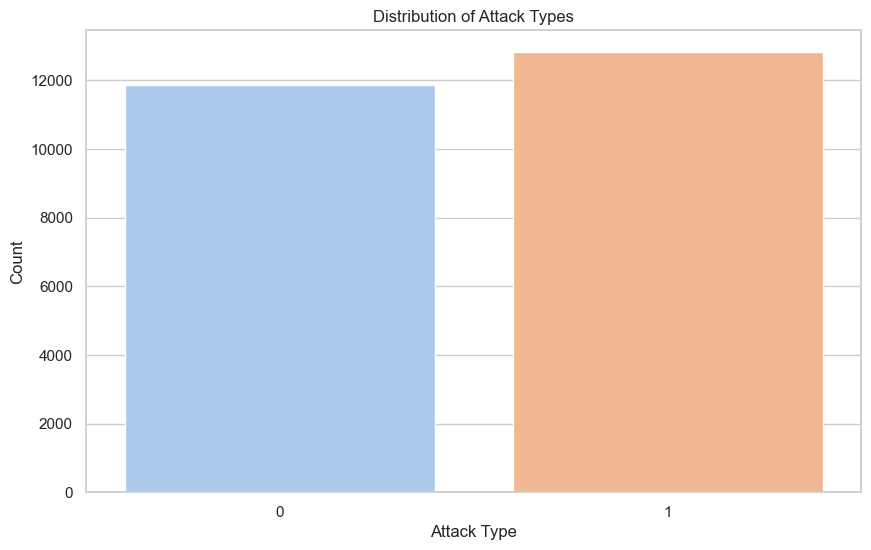

In [63]:
# Create the countplot
plt.figure(figsize=(10, 6))
sns.countplot(x=y_pred_string, palette="pastel")

# Add labels and title
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.title("Distribution of Attack Types")

# Show the plot
plt.show()

### Random Forest

Random Forest Results:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0


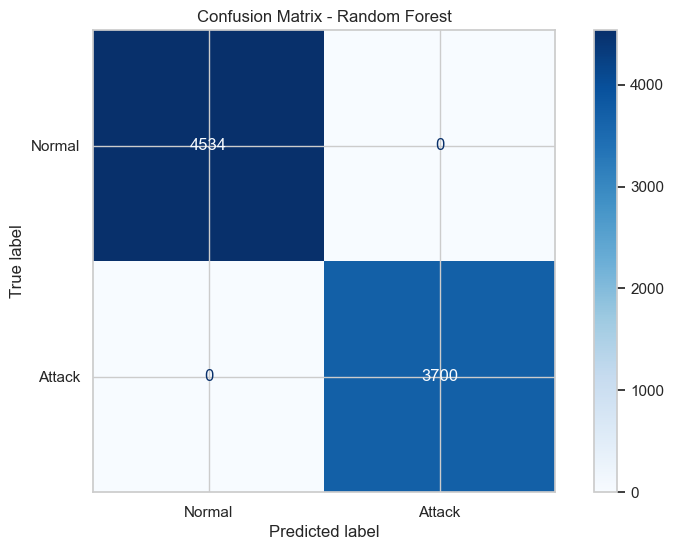

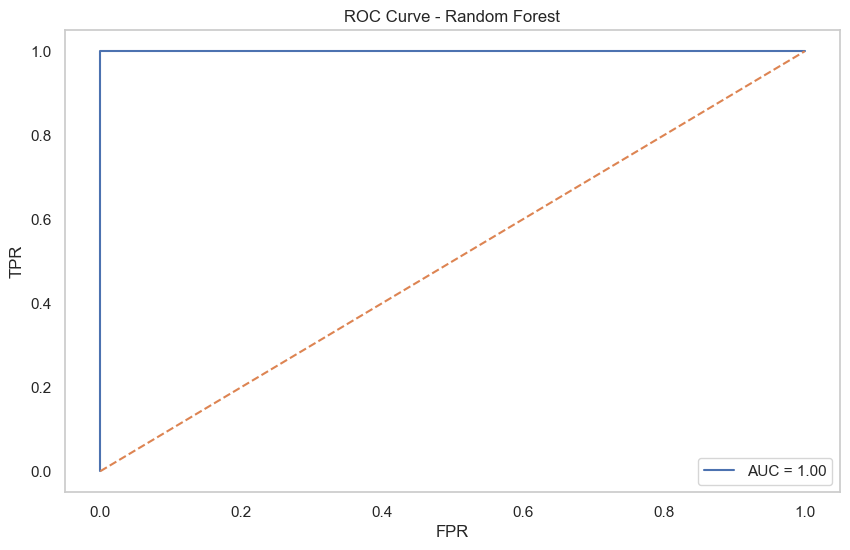

In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import *

# Model
rf_model = make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=100, random_state=42))
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_score_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_score_rf))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=["Normal", "Attack"], cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_score_rf)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_score_rf):.2f}")
plt.plot([0, 1], [0, 1], "--")
plt.title("ROC Curve - Random Forest")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid()
plt.show()


### MultiLayer Perception

Confusion Matrix:
[[4534    0]
 [   0 3700]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4534
           1       1.00      1.00      1.00      3700

    accuracy                           1.00      8234
   macro avg       1.00      1.00      1.00      8234
weighted avg       1.00      1.00      1.00      8234

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
ROC-AUC: 1.0000
Multilayer Perceptron Results:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0


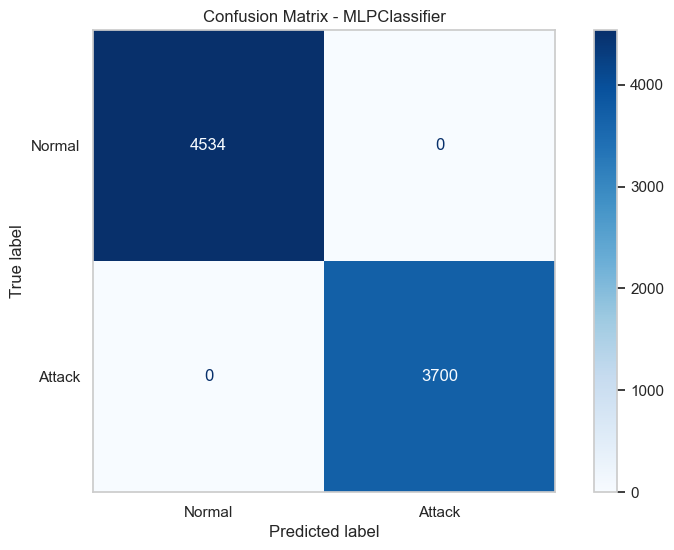

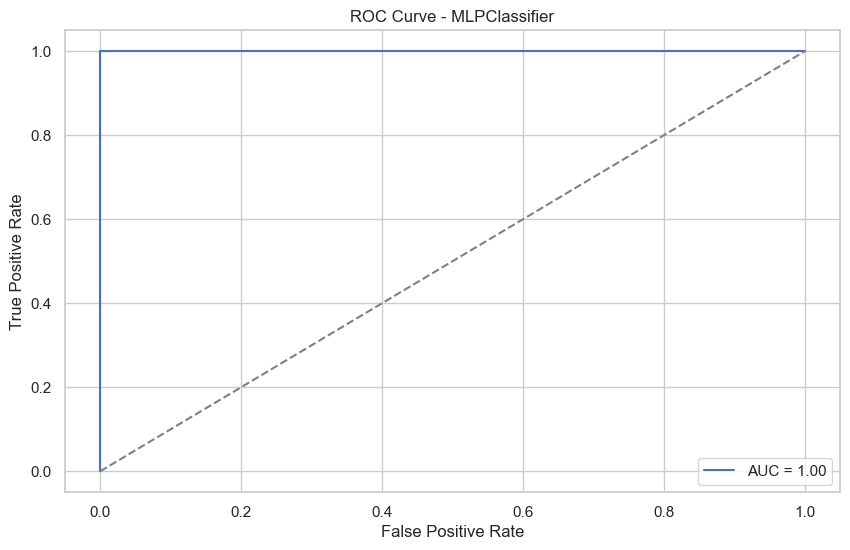

In [69]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Train
MLP_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)
MLP_model.fit(X_train_scaled, y_train)

# Quick eval (uses your helper)
evaluate_model(MLP_model, X_test_scaled, y_test)

# --- Optional: explicit metrics & plots ---
y_pred_mlp  = MLP_model.predict(X_test_scaled)               # use SAME scaler as training
y_score_mlp = MLP_model.predict_proba(X_test_scaled)[:, 1]   # MLPClassifier supports predict_proba

print("Multilayer Perceptron Results:")
print("Accuracy:",  accuracy_score(y_test, y_pred_mlp))
print("Precision:", precision_score(y_test, y_pred_mlp))
print("Recall:",    recall_score(y_test, y_pred_mlp))
print("F1 Score:",  f1_score(y_test, y_pred_mlp))
print("ROC-AUC:",   roc_auc_score(y_test, y_score_mlp))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_mlp, display_labels=["Normal", "Attack"], cmap="Blues"
)
plt.title("Confusion Matrix - MLPClassifier")
plt.grid(False)
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_score_mlp)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_score_mlp):.2f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.title("ROC Curve - MLPClassifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


### LightGBM

In [70]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


[LightGBM] [Info] Number of positive: 33300, number of negative: 40798
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018538 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6137
[LightGBM] [Info] Number of data points in the train set: 74098, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.449405 -> initscore=-0.203076
[LightGBM] [Info] Start training from score -0.203076
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

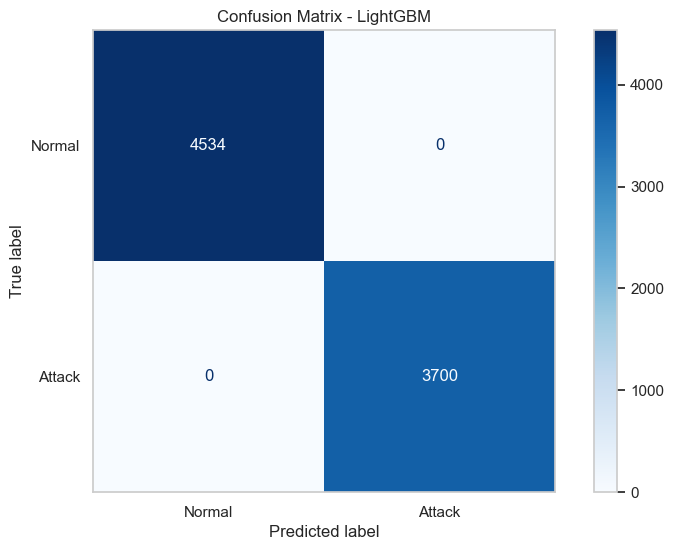

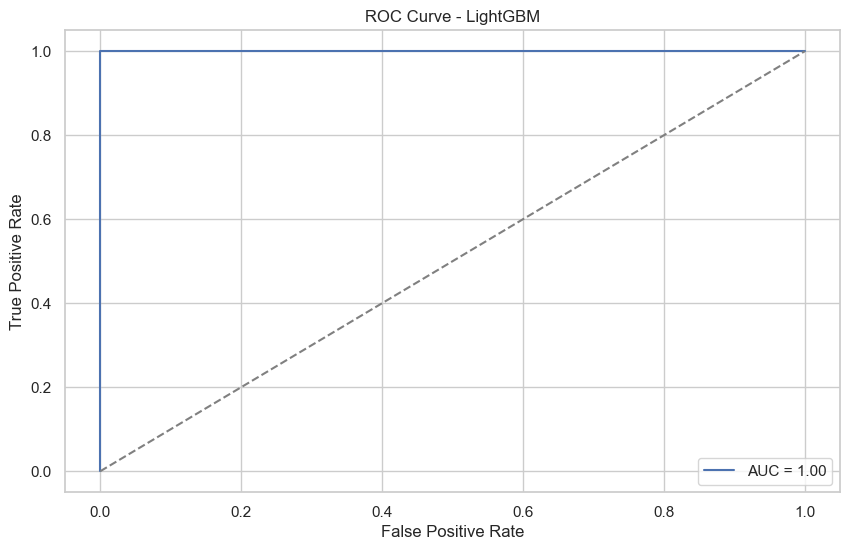

In [73]:
import lightgbm as lgb
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Train
LGB_model = lgb.LGBMClassifier(random_state=42)
LGB_model.fit(X_train_scaled, y_train)

# Quick eval (your helper)
evaluate_model(LGB_model, X_test_scaled, y_test)

# --- Optional: explicit metrics & plots ---
y_pred_lgb  = LGB_model.predict(X_test_scaled)                # use *scaled* test features
y_score_lgb = LGB_model.predict_proba(X_test_scaled)[:, 1]

print("LightGBM Classifier Results:")
print("Accuracy:",  accuracy_score(y_test, y_pred_lgb))
print("Precision:", precision_score(y_test, y_pred_lgb))
print("Recall:",    recall_score(y_test, y_pred_lgb))
print("F1 Score:",  f1_score(y_test, y_pred_lgb))
print("ROC-AUC:",   roc_auc_score(y_test, y_score_lgb))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lgb, display_labels=["Normal", "Attack"], cmap="Blues"
)
plt.title("Confusion Matrix - LightGBM")
plt.grid(False)
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_score_lgb)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_score_lgb):.2f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.title("ROC Curve - LightGBM")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


In [70]:
pip install catboost


Note: you may need to restart the kernel to use updated packages.


### Cat Boost(Optional)

Confusion Matrix:
[[4534    0]
 [   0 3700]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4534
           1       1.00      1.00      1.00      3700

    accuracy                           1.00      8234
   macro avg       1.00      1.00      1.00      8234
weighted avg       1.00      1.00      1.00      8234

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
ROC-AUC: 1.0000


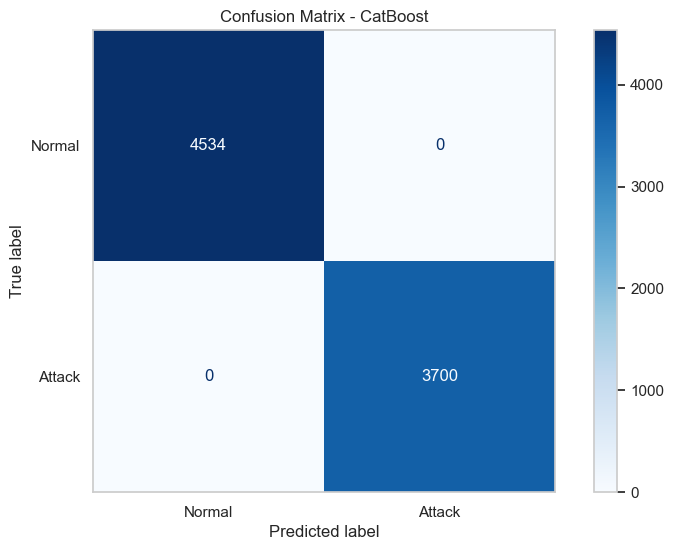

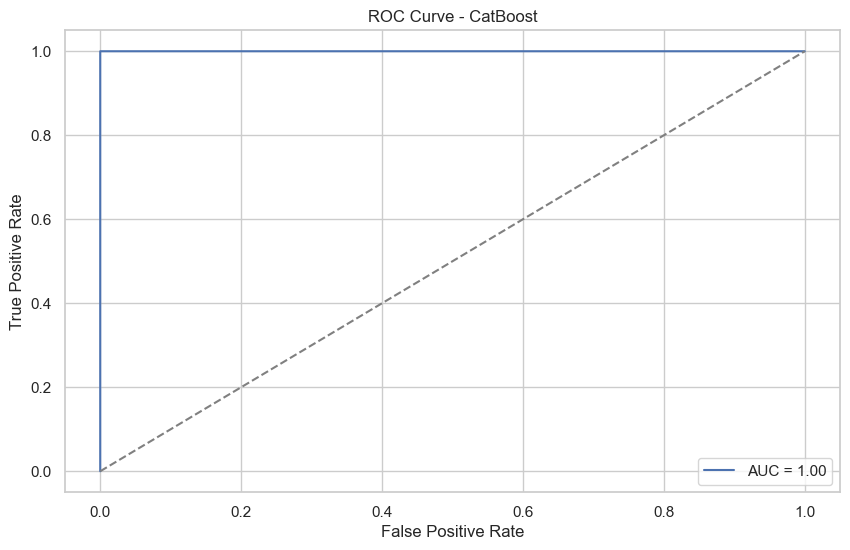

In [74]:
# Imports
from catboost import CatBoostClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# STEP 1: Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# STEP 2: Initialize and train the model
cb_model = CatBoostClassifier(verbose=0, random_state=42)
cb_model.fit(X_train_scaled, y_train)

# STEP 3: Make predictions
y_pred_cb = cb_model.predict(X_test_scaled)
y_score_cb = cb_model.predict_proba(X_test_scaled)[:, 1]

# STEP 4: Evaluation metrics
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_cb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_cb))

print(f"Accuracy: {accuracy_score(y_test, y_pred_cb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_cb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_cb):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_cb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_score_cb):.4f}")

# STEP 5: Confusion Matrix Plot
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_cb, display_labels=["Normal", "Attack"], cmap="Blues")
plt.title("Confusion Matrix - CatBoost")
plt.grid(False)
plt.show()

# STEP 6: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_score_cb)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_score_cb):.2f}")
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CatBoost")
plt.legend()
plt.grid(True)
plt.show()


### Comparison graph for XGBoost, MLP, Random Forest and LightGBM

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
1,LightGBM,1.0000,1.0000,1.0000,1.0000,1.0000
2,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
3,MLP,1.0000,1.0000,1.0000,1.0000,1.0000
0,XGBoost,0.9368,0.9677,0.9154,0.9409,0.9870


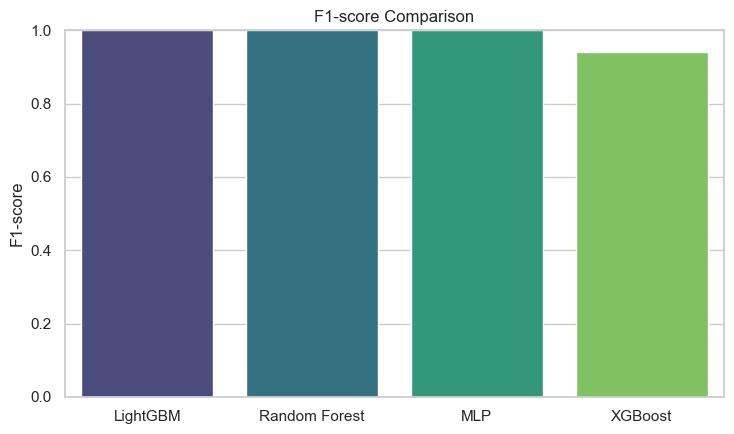

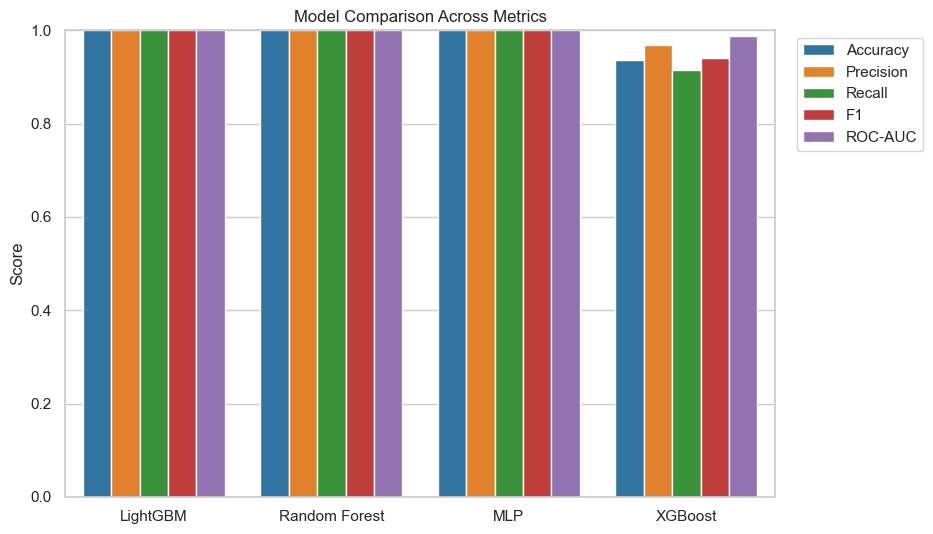

In [76]:
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set(style="whitegrid")

results_df = pd.DataFrame([
    {"Model": "XGBoost",       "Accuracy": 0.9368, "Precision": 0.9677, "Recall": 0.9154, "F1": 0.9409, "ROC-AUC": 0.9870},
    {"Model": "LightGBM",      "Accuracy": 1.0000, "Precision": 1.0000, "Recall": 1.0000, "F1": 1.0000, "ROC-AUC": 1.0000},
    {"Model": "Random Forest", "Accuracy": 1.0000, "Precision": 1.0000, "Recall": 1.0000, "F1": 1.0000, "ROC-AUC": 1.0000},
    {"Model": "MLP",           "Accuracy": 1.0000, "Precision": 1.0000, "Recall": 1.0000, "F1": 1.0000, "ROC-AUC": 1.0000},
]).sort_values("F1", ascending=False)

# Show table
display(results_df.style.format({c: "{:.4f}" for c in results_df.columns if c != "Model"}))

# F1 bar
plt.figure(figsize=(7.5, 4.5))
sns.barplot(data=results_df, x="Model", y="F1", palette="viridis")
plt.ylim(0,1); plt.title("F1-score Comparison"); plt.ylabel("F1-score"); plt.xlabel(""); plt.tight_layout(); plt.show()

# Grouped bars across metrics
melted = results_df.melt(id_vars=["Model"], value_vars=["Accuracy","Precision","Recall","F1","ROC-AUC"],
                         var_name="Metric", value_name="Score")
plt.figure(figsize=(9.5, 5.5))
sns.barplot(data=melted, x="Model", y="Score", hue="Metric", palette="tab10")
plt.ylim(0,1); plt.title("Model Comparison Across Metrics"); plt.ylabel("Score"); plt.xlabel("")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left"); plt.tight_layout(); plt.show()


In [72]:

# # Intrusion Detection using UNSW-NB15 Dataset (Modified Version)
# # Clean, original structure: Loads, preprocesses, trains, and compares 5 ML models

# import pandas as pd
# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt

# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import make_pipeline

# from sklearn.linear_model import LogisticRegression
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.svm import SVC
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.neural_network import MLPClassifier

# from sklearn.metrics import (
#     accuracy_score, precision_score, recall_score,
#     f1_score, roc_auc_score, roc_curve
# )

# # 🧩 Load UNSW-NB15 training set
# # df = pd.read_csv("UNSW_NB15_training-set.csv")
# df = pd.read_csv("/Users/premkumaraskani/Downloads/Kadhar_Final_code/UNSW_NB15_training-set.csv")
# df.dropna(inplace=True)
# df['class'] = df['attack_cat'].apply(lambda x: 0 if x == 'Normal' else 1)
# df.drop(columns=['id', 'attack_cat'], inplace=True, errors='ignore')

# # Features and target
# X = df.drop(columns='class')
# y = df['class']

# # Categorical and numeric features
# cat_features = X.select_dtypes(include='object').columns.tolist()
# num_features = X.select_dtypes(include=np.number).columns.tolist()

# # Preprocessing
# preprocessor = ColumnTransformer([
#     ('num', StandardScaler(), num_features),
#     ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_features)
# ])

# # Train-test split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.3, random_state=42, stratify=y
# )

# # Models to train
# models = {
#     "Logistic Regression": LogisticRegression(max_iter=1000),
#     "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
#     "Support Vector Machine": SVC(probability=True),
#     "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
#     "Multilayer Perceptron": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)
# }

# # Performance summary
# results = []

# for name, model in models.items():
#     pipeline = make_pipeline(preprocessor, model)
#     pipeline.fit(X_train, y_train)

#     y_pred = pipeline.predict(X_test)
#     y_score = pipeline.predict_proba(X_test)[:, 1]

#     acc = accuracy_score(y_test, y_pred)
#     prec = precision_score(y_test, y_pred)
#     rec = recall_score(y_test, y_pred)
#     f1 = f1_score(y_test, y_pred)
#     auc = roc_auc_score(y_test, y_score)

#     results.append({
#         "Model": name,
#         "Accuracy": acc,
#         "Precision": prec,
#         "Recall": rec,
#         "F1-Score": f1,
#         "ROC-AUC": auc
#     })

#     # Plot ROC
#     fpr, tpr, _ = roc_curve(y_test, y_score)
#     plt.figure()
#     plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
#     plt.plot([0, 1], [0, 1], '--')
#     plt.xlabel("False Positive Rate")
#     plt.ylabel("True Positive Rate")
#     plt.title(f"ROC Curve - {name}")
#     plt.legend()
#     plt.grid()
#     plt.show()

# # Results table
# results_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)
# print("=== Model Comparison Table ===")
# print(results_df)

# # Visualize F1-Scores
# plt.figure(figsize=(10, 5))
# sns.barplot(x='Model', y='F1-Score', data=results_df, palette='viridis')
# plt.title("F1-Score Comparison Across Models")
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()
